In [28]:
## Plot the results from the BNNs on one graph
from __future__ import annotations

import argparse
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import precision_recall_curve, average_precision_score

try:
    from sklearn.metrics import confusion_matrix
except ImportError as exc:  # pragma: no cover
    raise SystemExit("This script needs scikit-learn: pip install scikit-learn") from exc

In [29]:
df = pd.read_csv('echonext_metadata_100k.csv')

print(df.head())

   Unnamed: 0  ecg_key  patient_key  age_at_ecg     sex  acquisition_year  \
0           0  8520052    902618160          88    male              2014   
1           1  7283576   4764241080          69  female              2019   
2           2  8769869   4214459612          22    male              2017   
3           3  6379904   6205191619          70    male              2022   
4           4  9619545   8380688329          54    male              2013   

  location_setting race_ethnicity  most_recent_ecg  ventricular_rate  ...  \
0        emergency          other                1               117  ...   
1        inpatient          black                0                99  ...   
2        inpatient          white                0                86  ...   
3        emergency       hispanic                0                68  ...   
4        inpatient          other                0                90  ...   

   tricuspid_regurgitation_value  pulmonary_regurgitation_value  \
0      

In [52]:
df['shd_moderate_or_greater_flag']

0        0
1        0
2        1
3        1
4        1
        ..
99995    0
99996    0
99997    1
99998    1
99999    1
Name: shd_moderate_or_greater_flag, Length: 100000, dtype: int64

0 sex
1 age_at_ecg
2 pr_interval
3 qrs_duration
4 qt_corrected
5 atrial_rate
6 ventricular_rate
7 pericardial_effusion_value
8 ivs_measurement
9 lvpw_measurement
10 lvef_value
11 shd_moderate_or_greater_flag


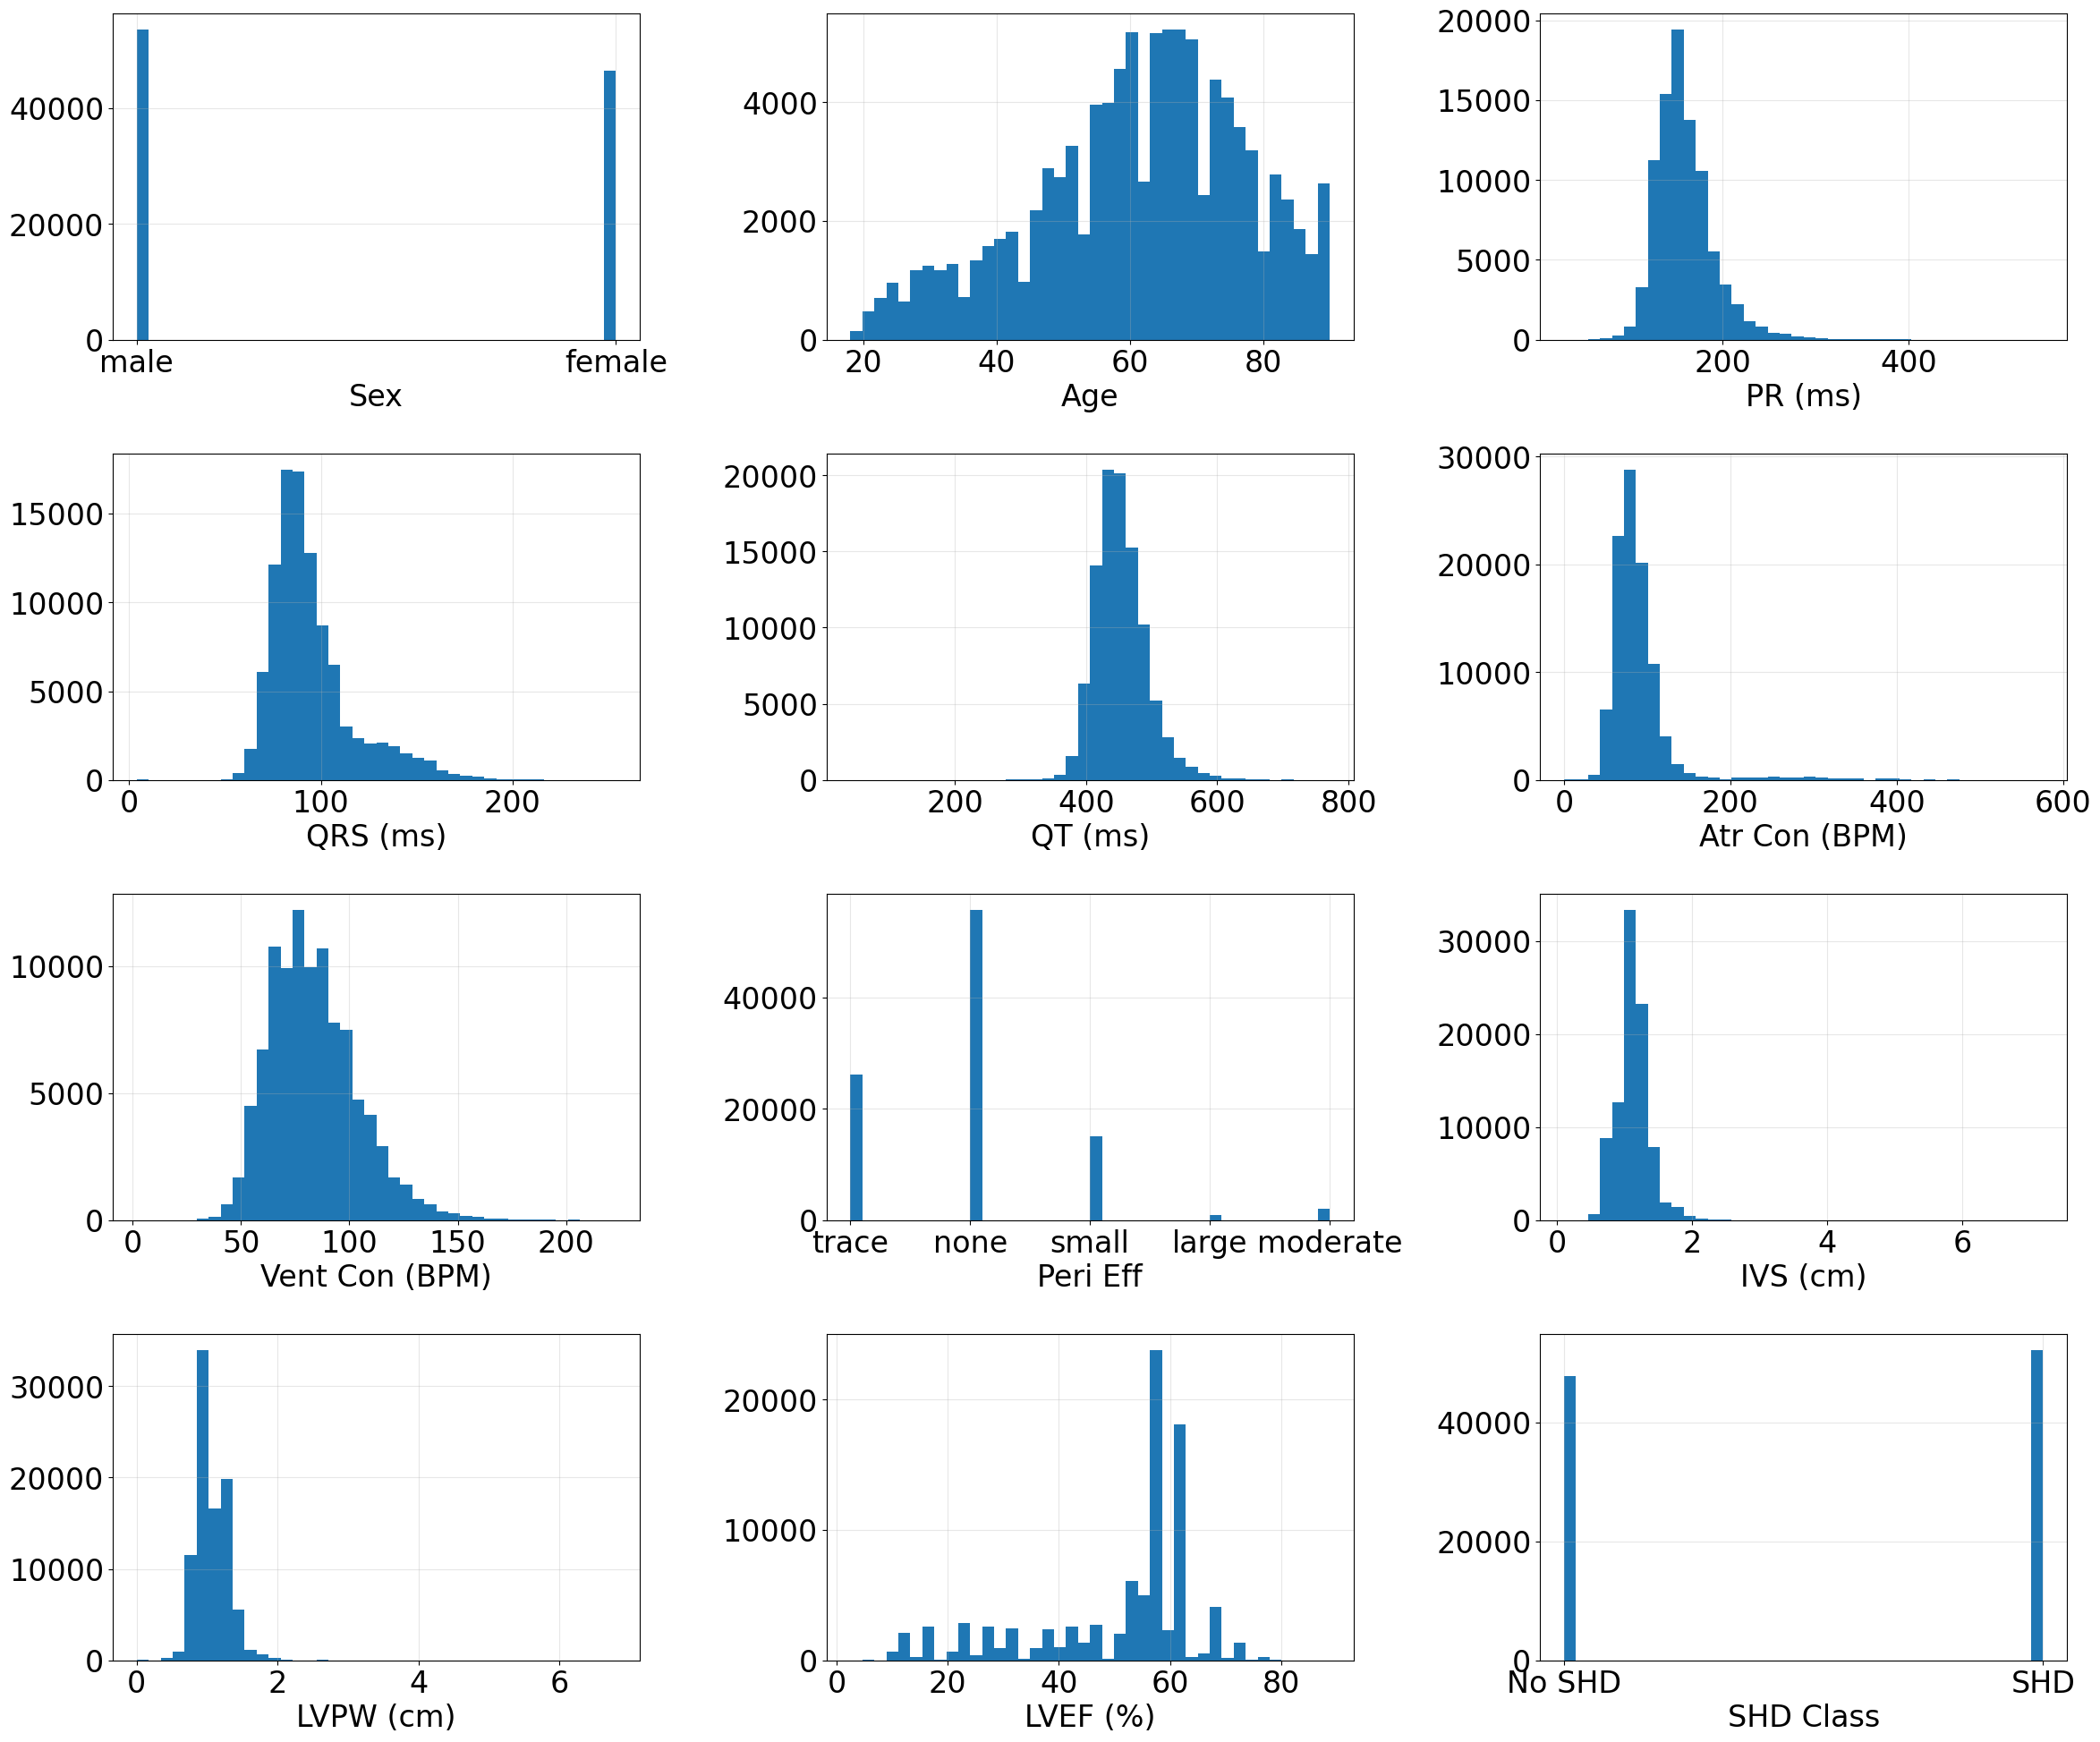

In [ ]:
plt.rcParams['font.size'] = 24
plt.figure(figsize=(24,20))
feat_names = ['sex','age_at_ecg','pr_interval','qrs_duration','qt_corrected','atrial_rate',
              'ventricular_rate','pericardial_effusion_value','ivs_measurement','lvpw_measurement','lvef_value','shd_moderate_or_greater_flag']
plot_names= ['Sex','Age','PR (ms)','QRS (ms)','QT (ms)','Atr Con (BPM)',
              'Vent Con (BPM)','Peri Eff','IVS (cm)','LVPW (cm)','LVEF (%)','SHD Class']
df['pericardial_effusion_value'] = df['pericardial_effusion_value'].fillna("none")
for i in range(len(feat_names)):
    plt.subplot(4,3,i+1)
    print(i,feat_names[i])
    plt.hist(df[feat_names[i]],bins=40)
    plt.xlabel(plot_names[i])
    plt.axis = 'tight'
    plt.grid(True, alpha=0.3)

# 
plt.subplot(4,3,12)
plt.xticks([0,1],['No SHD','SHD'])
plt.tight_layout()
plt.savefig("PaperFigures/data_distribution",dpi=300)
plt.show()

In [ ]:
pl